# Experiência de polarizadores

Neste exercício, vamos simular a experiência de passar um fotão por vários polarizadores não-alinhados.

Apesar de não termos um laboratório para simular um fotão de cada vez, podemos tentar fazê-lo com um computador quântico.

Começamos por instalar e importar as bibliotecas necessárias.

In [1]:
%%capture
%pip install qiskit

In [2]:
import numpy as np
from string import ascii_letters, digits
from matplotlib import pyplot as plt
from qiskit.visualization import plot_histogram
from qiskit import QuantumCircuit , QuantumRegister, ClassicalRegister
from qiskit.primitives import StatevectorSampler
sampler = StatevectorSampler()

## Experiência dos três polarizadores

Começamos por considerar uma experiência de três polarizadores:
  - Polarizador 1: eixo de polarização horizontal
  - Polarizador 2: eixo de polarização a $45^\circ$ com a horizontal
  - Polarizador 3: eixo de polarização a $90^\circ$ com a horizontal (vertical)

Vamos assumir que $|0\rangle = |H\rangle$ e $|1\rangle = |V\rangle$.

Como a luz chega ao primeiro polarizador sem polarização definida, podemos assumir que o primeiro polarizador está apenas a preparar o estado $|H\rangle$.

Assim, não precisamos de simular o primeiro polarizador.
Vamos assumir que passam 10000 fotões pelo primeiro.



In [3]:
# Primeiro polarizador: prepara estado |H>
fotoes1 = 10_000



No entanto, os outros dois polarizadores funcionam como uma medida numa base $\theta$, isto é, correspondem a medir na base
\begin{align}
|H_\theta\rangle &= \phantom{-} \cos\theta \, |H\rangle + \sin\theta \, |V\rangle \\
|V_\theta\rangle &= -\sin\theta \, |H\rangle + \cos\theta \, |V\rangle.
\end{align}

Habitualmente, os computadores quânticos medem na base computacional apenas, o que quer dizer que temos de aplicar uma unitária para poder medir nesta bases.

Então, que unitária devemos escolher? A resposta é simples: é a operação inversa à operação $U$ que prepara os estados $|H_\theta\rangle, |V_\theta\rangle.$

Neste caso, temos
$$
U(\theta)
=
\begin{pmatrix}
\cos\theta & -\sin\theta \\
\sin\theta & \phantom{-}\cos\theta
\end{pmatrix}.
$$

Felizmente, esta operação existe já por defeito no Qiskit, sob um outro nome.
De facto, existe a operação
$$
R_y(\theta)
=
\begin{pmatrix}
\cos(\theta/2) & -\sin(\theta/2) \\
\sin(\theta/2) & \phantom{-}\cos(\theta/2),
\end{pmatrix}
$$
pelo que, para medir na base $\theta$, devemos aplicar a operação
$$
U^\dagger(\theta)
=
U(-\theta)
=
R_y(-2\theta).
$$

Assim, quando medirmos $|0\rangle$ no final do circuito, sabemos que estamos na verdade a medir $|H_\theta\rangle$, e, se medirmos $|1\rangle$, estamos na verdade a medir $|V_\theta\rangle$.

Desenhamos então o circuito que corresponde aos fotões a chegar ao segundo polarizador.

In [4]:
# Segundo polarizador: a 45 graus do primeiro

qc2 = QuantumCircuit(1)
qc2.ry(-2 * np.radians(45), 0)  # Medição a 45 graus
qc2.measure_all()
qc2.draw()

┌──────────┐ ░ ┌─┐
     q: ┤ Ry(-π/2) ├─░─┤M├
        └──────────┘ ░ └╥┘
meas: 1/════════════════╩═
                        0

Vamos simular 10 000 fotões a passar do primeiro polarizador para o segundo.

Quantos destes passam pelo segundo polarizador?
Temos de correr a simulação

In [5]:
job = sampler.run([qc2], shots=fotoes1)
result = job.result()[0]
fotoes2 = result.data.meas.get_counts().get('0', 0)

fotoes2

4972

Podemos agora simular o terceiro polarizador, fazendo passar apenas os fotões que sobreviveram ao segundo polarizador.
É assim que simulamos uma medição _destrutiva_.

No entanto, esta situação é diferente do primeiro circuito que escrevemos.

Agora, temos:
  - Um fotão a chegar com polarização linear no ângulo $\theta$ com a horizontal
  - Um polarizador num ângulo $\theta'$ com a horizontal.

Isto quer dizer que agora temos primeiro de preparar o estado certo, e só depois é que medimos na base que queremos (que será agora a $\theta' = 90^\circ$!).

In [6]:
# Terceiro polarizador: a 90 graus do primeiro

qc3 = QuantumCircuit(1)
qc3.ry(2 * np.radians(45), 0)  # Preparar o fotão a 45 graus
qc3.ry(-2 * np.radians(90), 0)  # Medir na base a 90 graus
qc3.measure_all()
qc3.draw()

┌─────────┐┌────────┐ ░ ┌─┐
     q: ┤ Ry(π/2) ├┤ Ry(-π) ├─░─┤M├
        └─────────┘└────────┘ ░ └╥┘
meas: 1/═════════════════════════╩═
                                 0

In [7]:
job = sampler.run([qc3], shots=fotoes2)
result = job.result()[0]
fotoes3 = result.data.meas.get_counts().get('0', 0)

fotoes3

2541

Isto quer dizer que esperamos que apenas aproximadamente 25\% dos fotões passam intactos do primeiro para o último polarizador.


## (exercício 1) Dois polarizadores

Neste problema é simulada a situação em que fotões no estado horizontal passam por um polarizador vertical. É simulada a passagem de 10000 fotões.

1.a) Criação do circuito


O primeiro polarizador não é simulado, pois apenas serve para preparar os fotões no estado horziontal (|H⟩ = |0⟩). Assim, na prática, só é necessario construir o circuito correspondente ao segundo polarizador,ou seja, a uma medição numa base rodada a 90◦

In [16]:
# Primeiro polarizador: prepara estado horizontal
NSHOTS = 10000
sampler = StatevectorSampler()
qreg = QuantumRegister(1, 'q')  # Qubit
creg = ClassicalRegister(1, 'meas')  # Bit clássico -- para guardar resultados de medições
qc = QuantumCircuit(qreg, creg, name='polarizador')

#preparar(redundante)
angulo = np.radians(0)
qc.ry(2*angulo, qreg[0])

#medir
angulo = np.radians(90)
qc.ry(-2*angulo, qreg[0])
qc.measure(qreg[0], creg[0])

1.b) Simulação

O circuito é então simulado com 10000 fotões que passam pelo primeiro polarizador. O resultado imprimido é o número de vezes que os fotões passados pelo circuito de dois polarizadores têm medida '0'.

In [11]:
job = sampler.run([qc], shots=NSHOTS)
#job.status()
result = job.result()[0]
outcomes = result.data.meas.get_counts()
num_0 = outcomes.get('0', 0)

print(f'Número de 0s do segundo circuito: {num_0}')


Número de 0s do segundo circuito: 0


1.c) Comentário  
  
É possível verificar que o número de fotões que passam pelo segundo polarizador é sempre 0. Isto acontece uma vez que o estado $|H\rangle$ (representa a polarização horizontal), é ortogonal à base do estado $|V\rangle$ (representa a polarização vertical). Assim, quando um fotão polarizado na direção horizontal é enviado através de um polarizador orientado na direção vertical, a probabilidade de o fotão passar é nula. Passam assim sempre menos fotões quando comparada com a experiência de três polarizadores.



## (2) Quatro polarizadores

O primeiro polarizador não é simulado, pois apenas serve para preparar os fotões no estado horziontal. Assim, repito a análise mas com quatro polarizadores, a $30^\circ$ entre si. Ângulos = [$0^\circ$,$30^\circ$,$60^\circ$,$90^\circ$ ]


2.a)Criar e simular os 3 circuitos (30º, 60º e 90º) em que o número de fotões medidos com '0' num circuto é o numero de $shots$ para o circuito seguinte.

In [12]:
NSHOTS = 10000

print("Após passar por um polarizador a 0 graus:", NSHOTS)
for i in range(3):
    cur_qc = QuantumCircuit(1)
    cur_qc.ry(2 * i * np.radians(30), 0)
    cur_qc.ry(-2 * (i+1) * np.radians(30), 0)
    cur_qc.measure_all()
    job = sampler.run([cur_qc], shots = NSHOTS)
    result = job.result()[0]
    NSHOTS = result.data.meas.get_counts().get('0', 0) #num_0
    print("Após passar pelo polarizador a", (i+1) * 30, "graus, preparado a", i * 30, "graus:", NSHOTS, "fotões")

print("Número final de fotões a passar pelo circuito:", NSHOTS)


Após passar por um polarizador a 0 graus: 10000
Após passar pelo polarizador a 30 graus, preparado a 0 graus: 7525 fotões
Após passar pelo polarizador a 60 graus, preparado a 30 graus: 5631 fotões
Após passar pelo polarizador a 90 graus, preparado a 60 graus: 4195 fotões
Número final de fotões a passar pelo circuito: 4195


2.b) Comentário:
  
Em comparação à experiência de três polarizadores, com quatro polarizadores passa uma maior percentagem dos fotões iniciais.
Isto deve-se à probabilidade de um fotão passar através de um polarizador com um ângulo $\theta$ em relação à sua polarização ser $\cos^2(\theta)$. O que significa que quanto menor for $\theta$ mais fotões passam pelo polarizador.
Nas experiências realizadas, $\theta = \frac{90º}{n}$ (onde $n+1$ é o número de polarizadores, devido ao estado inicial), então, o número esperado $F_{n+1}$ de fotões que passam pelos $n + 1$ polarizadores é dado por $F_0 {\cos(\frac{90º}{n})}^{2n}$. Com isto confirma-se que o número de fotões que "sobrevivem" na primeira experiência (3 polarizadores) $F_{3}$ é menor do que com quatro polarizadores  $F_{4}$, porque $F_0 {\cos(45)}^{4} < F_0 {\cos(30)}^{6}$

## (3) Caso geral de $n+1$ polarizadores (opcional)

3.a) Função em que um fotão é preparado com polarização linear $\theta$ com a horizontal e depois é medido na base rodada num ângulo $\theta'$.

In [13]:
def qc_polarizador(theta, theta_):
  cur_qc = QuantumCircuit(1)
  cur_qc.ry(2*np.radians(theta), 0)
  cur_qc.ry(-2*np.radians(theta_), 0)
  cur_qc.measure_all()


  return cur_qc
qc_polarizador(30,60).draw()

┌─────────┐┌───────────┐ ░ ┌─┐
     q: ┤ Ry(π/3) ├┤ Ry(-2π/3) ├─░─┤M├
        └─────────┘└───────────┘ ░ └╥┘
meas: 1/════════════════════════════╩═
                                    0

É obtido o mesmo circuito da penúltima iteração do exercício $2a)$. Nessa iteração os fotão também foram preparados com polarização linear $\theta$=30º com a horizontal e medidos na base rodada pelo angulo 60º.

3.b) Função para uma experiência de $n+1$ polarizadores que devolve o número de fotões que sobrevivem a todos os polarizadores.

(Apenas são precisos $n$ circuitos, pois o primeiro polarizador não é simulado.)

In [14]:
def experiencia_polarizadores(n, numshots):
  NSHOTS = numshots
  angle = 0
  if n > 0:
    angle = 90/n

  for i in range(n): #n+1
    cur_qc = qc_polarizador(i*angle, (i+1)*angle)
    job = sampler.run([cur_qc], shots=NSHOTS)
    result = job.result()[0]
    NSHOTS = result.data.meas.get_counts().get('0', 0)
  return NSHOTS

3.c) Simular os casos $n=1,2,\ldots, 10$

In [15]:
n = 10
nshots = 10000
fotoes_finais = []
for i in range(1, n+1):
    cur = experiencia_polarizadores(i, nshots)
    print("n + 1 =", i+1, "polarizadores ->", cur, "fotões") # + 1 para o polarizador de preparação horizontal
    fotoes_finais.append(cur) #para o plot

n + 1 = 2 polarizadores -> 0 fotões
n + 1 = 3 polarizadores -> 2516 fotões
n + 1 = 4 polarizadores -> 4208 fotões
n + 1 = 5 polarizadores -> 5384 fotões
n + 1 = 6 polarizadores -> 6085 fotões
n + 1 = 7 polarizadores -> 6602 fotões
n + 1 = 8 polarizadores -> 7083 fotões
n + 1 = 9 polarizadores -> 7339 fotões
n + 1 = 10 polarizadores -> 7589 fotões
n + 1 = 11 polarizadores -> 7695 fotões


Para a simulação dos casos $n=1,2,…,10$ observa-se que o número de fotões "sobreviventes" aumenta conforme cresce o número de polarizadores inseridos. Isto deve-se à função que descreve a probabilidade de um fotão sobreviver após $n+1$ polarizadores ser $S(n+1) = {\cos(\frac{90º}{n})}^{2n}$. $S(n+1)$, que é estritamente crescente para $n > 0$. No entanto conforme n cresce há uma aproximação do limite da função havendo um "achatamento" do aumento de número de fotões (o mesmo acontece com a dimnuição de fotões aquando o aumento do ângulo no exercício 2.a)

3.d) Gráfico de resultados

Representa a percentagem de fotões sobreviventes em função do angulo $\alpha(n)$

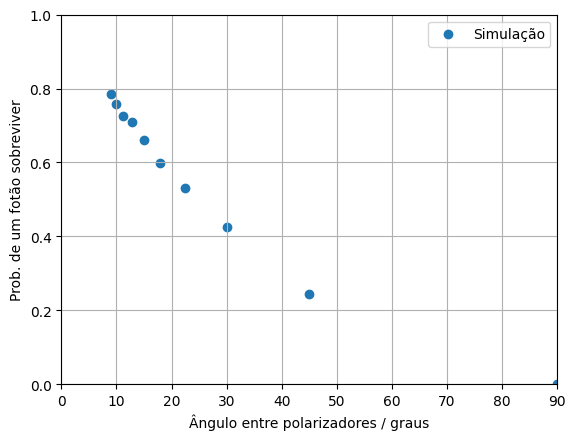

In [ ]:
xdata = []
for i in range(1, n+1):
    xdata.append(90/i)

ydata = np.array(fotoes_finais) / 10000

fig, ax = plt.subplots()

# Plot das simulações
plt.scatter(xdata, ydata, label='Simulação')

ax.set_xlim([0, 90])
ax.set_ylim([0, 1])
ax.set_xlabel('Ângulo entre polarizadores (graus)')
ax.set_ylabel('Prob. de um fotão sobreviver')

ax.legend()
ax.grid()

plt.show()


Verifica-se assim que a probabilidade de um fotão sobreviver diminui com o aumento do ângulo entre polarizadores.